In [2]:
!pip install transformers datasets evaluate accelerate -q

In [9]:
# Download the dataset files


import torch
import pandas as pd
import numpy as np
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)

# 1. Hardware Setup (MUST SHOW 'cuda')
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Load Data (Twitter Dataset)
cols = ['id', 'entity', 'sentiment', 'text']
# We use engine='python' to avoid parsing errors with emojis/special chars
train_df = pd.read_csv('twitter_training.csv', header=None, names=cols, engine='python').dropna(subset=['text'])
valid_df = pd.read_csv('twitter_validation.csv', header=None, names=cols, engine='python').dropna(subset=['text'])

# Label Encoding
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['sentiment'])
valid_df['label'] = le.transform(valid_df['sentiment'])
num_labels = len(le.classes_)

# Split Validation into Val and Test (Requirement: Train, Val, Test sets)
val_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df['label'], random_state=42)

# 3. Tokenization (bert-base-uncased)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = Dataset.from_pandas(train_df[['text', 'label']]).map(tokenize_fn, batched=True)
val_ds = Dataset.from_pandas(val_df[['text', 'label']]).map(tokenize_fn, batched=True)
test_ds = Dataset.from_pandas(test_df[['text', 'label']]).map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. Model Initialization Function (For Experiments)
def get_model(mode="last_two"):
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)

    if mode == "frozen":
        # EXPERIMENT: Freeze all BERT layers
        for param in model.bert.parameters():
            param.requires_grad = False
    elif mode == "last_two":
        # EXPERIMENT: Fine-tune only last 2 layers
        for param in model.bert.parameters():
            param.requires_grad = False
        for param in model.bert.encoder.layer[-2:].parameters():
            param.requires_grad = True

    return model.to(device)

# 5. Metrics Calculation (Handling Multi-class)
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

# 6. Training Arguments (Updated for latest Transformer versions)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,          # Mandatory Learning Rate
    per_device_train_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",       # Fix for TypeError
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True if torch.cuda.is_available() else False, # GPU speed boost
    report_to="none"
)



Using device: cuda


Map:   0%|          | 0/73996 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.367754,0.282000,0.198130
2,No log,1.366785,0.266000,0.161613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- FINAL TEST SET PERFORMANCE ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

  Irrelevant       0.00      0.00      0.00        86
    Negative       0.27      0.87      0.41       133
     Neutral       0.46      0.04      0.08       143
    Positive       0.25      0.11      0.15       138

    accuracy                           0.27       500
   macro avg       0.25      0.26      0.16       500
weighted avg       0.27      0.27      0.17       500



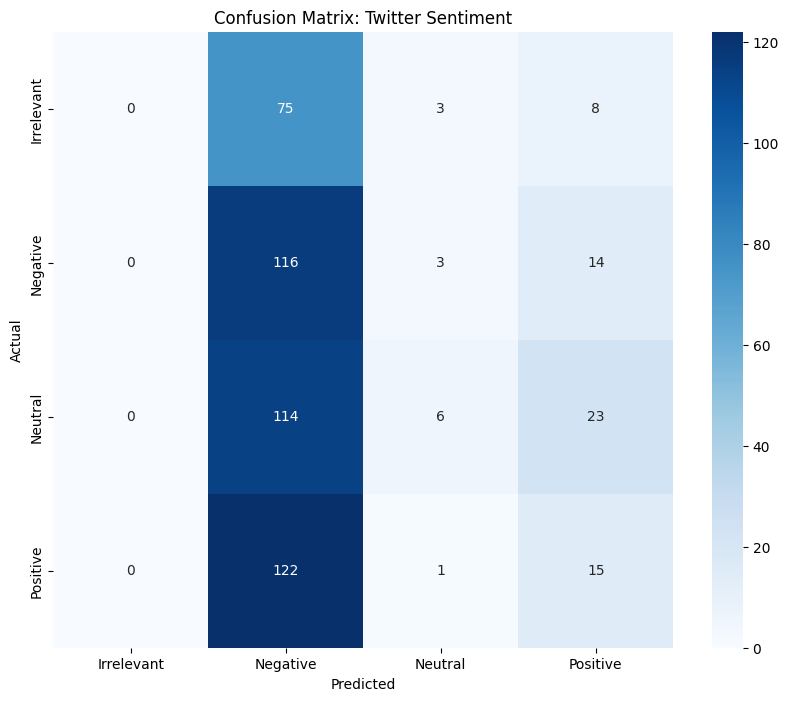

In [10]:
# 7. Training Execution (Run "last_two" first, then "frozen" for experiment comparison)
trainer = Trainer(
    model=get_model("frozen"),
    args=training_args,
    train_dataset=train_ds.shuffle(seed=42).select(range(5000)), # sampled for speed
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# 8. Evaluation & Confusion Matrix
print("\n--- FINAL TEST SET PERFORMANCE ---")
output = trainer.predict(test_ds)
y_preds = np.argmax(output.predictions, axis=-1)
y_true = output.label_ids

# Print Metrics
print(classification_report(y_true, y_preds, target_names=le.classes_))

# Confusion Matrix Visual
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Twitter Sentiment')
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.221898,0.494000,0.447275
2,No log,1.177486,0.534000,0.484391


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- FINAL TEST SET PERFORMANCE ---


              precision    recall  f1-score   support

  Irrelevant       0.00      0.00      0.00        86
    Negative       0.53      0.75      0.62       133
     Neutral       0.51      0.62      0.56       143
    Positive       0.56      0.55      0.56       138

    accuracy                           0.53       500
   macro avg       0.40      0.48      0.43       500
weighted avg       0.44      0.53      0.48       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


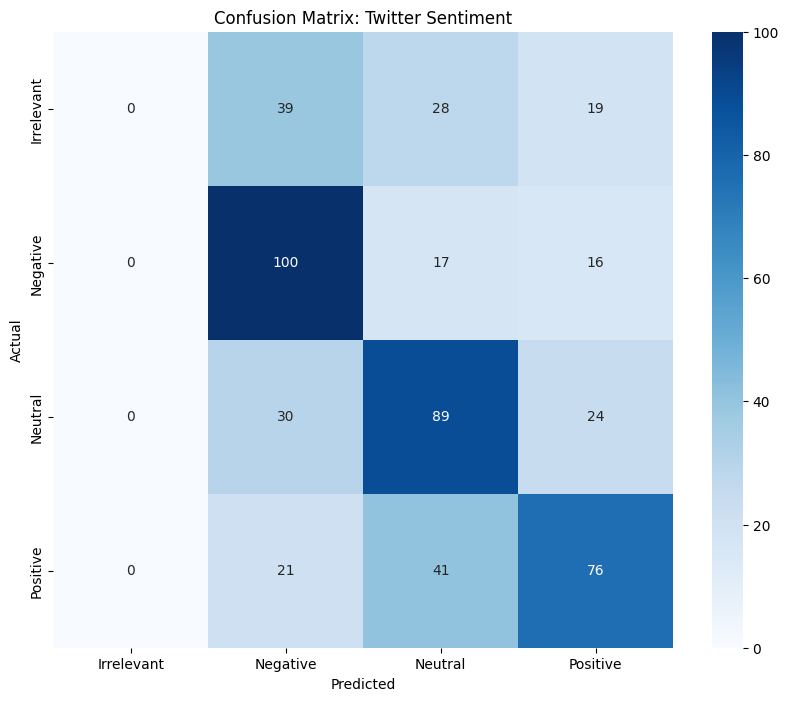

In [11]:
# 7. Training Execution (Run "last_two" first, then "frozen" for experiment comparison)
trainer = Trainer(
    model=get_model("last_two"),
    args=training_args,
    train_dataset=train_ds.shuffle(seed=42).select(range(5000)), # sampled for speed
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# 8. Evaluation & Confusion Matrix
print("\n--- FINAL TEST SET PERFORMANCE ---")
output = trainer.predict(test_ds)
y_preds = np.argmax(output.predictions, axis=-1)
y_true = output.label_ids

# Print Metrics
print(classification_report(y_true, y_preds, target_names=le.classes_))

# Confusion Matrix Visual
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Twitter Sentiment')
plt.show()

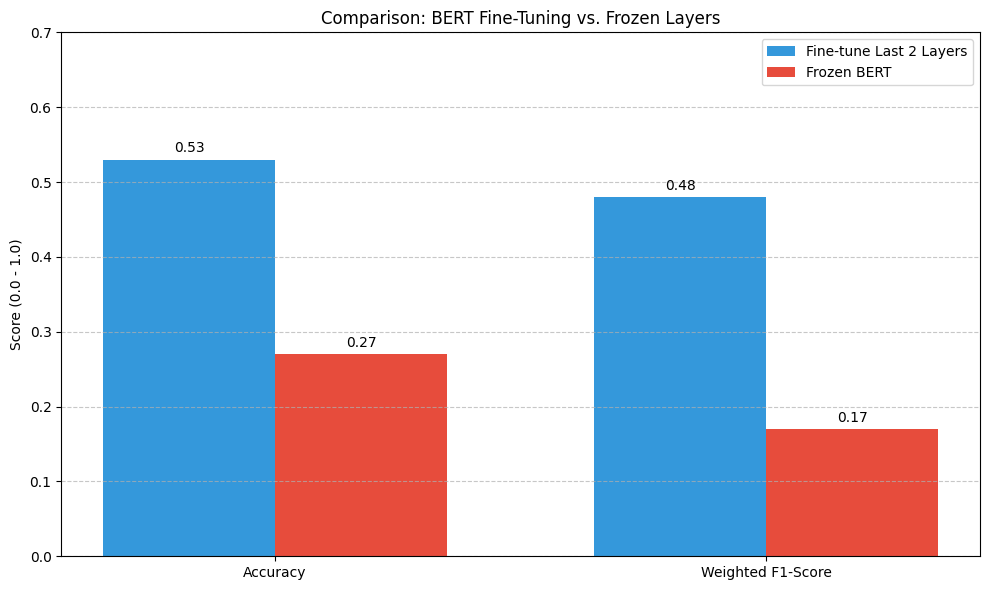

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your specific runs
labels = ['Accuracy', 'Weighted F1-Score']
last_two_results = [0.53, 0.48]  # Results from Experiment 1
frozen_results = [0.27, 0.17]    # Results from Experiment 2

x = np.arange(len(labels))  # Label locations
width = 0.35                # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, last_two_results, width, label='Fine-tune Last 2 Layers', color='#3498db')
rects2 = ax.bar(x + width/2, frozen_results, width, label='Frozen BERT', color='#e74c3c')

# Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Score (0.0 - 1.0)')
ax.set_title('Comparison: BERT Fine-Tuning vs. Frozen Layers')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.ylim(0, 0.7) # Adjust limit to see the difference clearly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()